# CityLearn Advanced System Identification Notebook

This notebook builds a more advanced, control-oriented system identification (SID) model for the CityLearn CE1 TX environment.

It improves the previous notebook in four ways:

1. **Persistently exciting data collection** using piecewise-random actions instead of weak zero-action data.
2. **NARX-style dynamic features** with temperature lags.
3. **Residual deep learning model**: a linear Ridge model plus a neural residual correction.
4. **MPC-relevant evaluation**: both one-step prediction and recursive free-running rollout.

Main target:

$$
T_{k+1} = f(T_k, T_{k-1}, \ldots, u^{cool}_k, u^{bat}_k, w_k)
$$

where weather/time/load variables are treated as known exogenous inputs. Battery SOC and many electricity balance equations should normally be kept analytical rather than learned from scratch.

## 0. Setup

Run this notebook from your project root, or edit `REPO_DIR` manually. The project root should contain the local `citylearn/` folder and the TX dataset folder.

This notebook uses CUDA automatically if available.

In [6]:
from pathlib import Path
import sys, os, json, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# Edit this manually if automatic detection fails.
REPO_DIR = None

HERE = Path.cwd()
if REPO_DIR is None:
    for p in [HERE] + list(HERE.parents):
        if (p / "citylearn").exists():
            REPO_DIR = p
            break

if REPO_DIR is None:
    raise FileNotFoundError("Could not find project root containing citylearn/. Set REPO_DIR manually.")

sys.path.insert(0, str(REPO_DIR))
from citylearn.citylearn import CityLearnEnv

# Dataset path detection.
CLIMATE = "TX"
candidates = [
    REPO_DIR / "data" / "datasets" / f"annex96_ce1_{CLIMATE.lower()}_neighborhood",
    REPO_DIR / f"annex96_ce1_{CLIMATE.lower()}_neighborhood",
    REPO_DIR / "annex96_ce1_tx_neighborhood",
]
DATASET_DIR = next((p for p in candidates if (p / "schema.json").exists()), None)
if DATASET_DIR is None:
    raise FileNotFoundError("Could not find annex96_ce1_tx_neighborhood/schema.json. Set DATASET_DIR manually.")
SCHEMA_PATH = DATASET_DIR / "schema.json"

print("REPO_DIR:", REPO_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("SCHEMA_PATH:", SCHEMA_PATH)

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
REPO_DIR: c:\Users\yusuf\Documents\Python_Projects\CITYLEARN - Q4\annex96_common_exercise_1
DATASET_DIR: c:\Users\yusuf\Documents\Python_Projects\CITYLEARN - Q4\annex96_common_exercise_1\data\datasets\annex96_ce1_tx_neighborhood
SCHEMA_PATH: c:\Users\yusuf\Documents\Python_Projects\CITYLEARN - Q4\annex96_common_exercise_1\data\datasets\annex96_ce1_tx_neighborhood\schema.json


## 1. Environment helpers

CityLearn versions differ slightly. Some expose `env.action_names` and `env.observation_names` per building; others expose flattened lists. The helpers below normalize these into per-building lists.

In [7]:
def make_env(central_agent=False):
    return CityLearnEnv(
        schema=str(SCHEMA_PATH),
        root_directory=str(DATASET_DIR),
        central_agent=central_agent
    )

def get_episode_range(env):
    tracker = getattr(env, "episode_tracker", None)

    start = getattr(env, "simulation_start_time_step", None)
    end = getattr(env, "simulation_end_time_step", None)

    if start is None and tracker is not None:
        start = getattr(tracker, "simulation_start_time_step", None)

    if end is None and tracker is not None:
        end = getattr(tracker, "simulation_end_time_step", None)

    return start, end


env = make_env(central_agent=False)
obs, info = env.reset()

n_buildings = len(env.buildings)

# ---------------------------------------------------------
# Observation/action names normalization
# ---------------------------------------------------------

OBS_NAMES = env.observation_names
ACTION_NAMES = env.action_names

# If flattened, split manually per building.
if isinstance(OBS_NAMES[0], str):
    obs_dim = len(env.observation_space[0].low)

    OBS_NAMES = [
        OBS_NAMES[i * obs_dim:(i + 1) * obs_dim]
        for i in range(n_buildings)
    ]

if isinstance(ACTION_NAMES[0], str):
    act_dim = len(env.action_space[0].low)

    ACTION_NAMES = [
        ACTION_NAMES[i * act_dim:(i + 1) * act_dim]
        for i in range(n_buildings)
    ]

OBS_INDEX = [
    {name: i for i, name in enumerate(names)}
    for names in OBS_NAMES
]

ACTION_INDEX = [
    {name: i for i, name in enumerate(names)}
    for names in ACTION_NAMES
]

# ---------------------------------------------------------
# Info prints
# ---------------------------------------------------------

sim_start, sim_end = get_episode_range(env)

print("Number of buildings:", n_buildings)
print("Episode range:", sim_start, sim_end)
print("env.time_steps:", getattr(env, "time_steps", None))

print("\nFirst building:", env.buildings[0].name)

print("\nAction names building 0:")
print(ACTION_NAMES[0])

print("\nObservation names building 0:")
for i, name in enumerate(OBS_NAMES[0]):
    print(f"{i:02d}: {name}")

# ---------------------------------------------------------
# Dynamics / LSTM inspection
# ---------------------------------------------------------

if hasattr(env.buildings[0], "dynamics"):
    dyn = env.buildings[0].dynamics

    print("\nDynamics class:", type(dyn))
    print("LSTM lookback:", getattr(dyn, "lookback", None))
    print("LSTM inputs:", getattr(dyn, "input_observation_names", None))

Number of buildings: 25
Episode range: 3624 4343
env.time_steps: 720

First building: resstock-amy2018-2021-release-1-6887

Action names building 0:
['electrical_storage', 'cooling_device']

Observation names building 0:
00: month
01: hour
02: outdoor_dry_bulb_temperature
03: direct_solar_irradiance
04: outdoor_dry_bulb_temperature_predicted_1
05: outdoor_dry_bulb_temperature_predicted_2
06: outdoor_dry_bulb_temperature_predicted_3
07: direct_solar_irradiance_predicted_1
08: direct_solar_irradiance_predicted_2
09: direct_solar_irradiance_predicted_3
10: indoor_dry_bulb_temperature
11: non_shiftable_load
12: dhw_demand
13: cooling_demand
14: heating_demand
15: solar_generation
16: indoor_dry_bulb_temperature_cooling_set_point
17: indoor_dry_bulb_temperature_heating_set_point
18: comfort_band
19: indoor_dry_bulb_temperature_cooling_delta
20: indoor_dry_bulb_temperature_heating_delta
21: hvac_mode
22: power_outage
23: electrical_storage_soc
24: net_electricity_consumption
25: cooling_elec

## 2. Variable interpretation

Use this mental model:

| Variable type | Examples | Should we identify it? |
|---|---|---|
| Exogenous/buffered | weather, solar, hour, month, forecasts | No; treat as known disturbances |
| Control inputs | `action_cooling_device`, `action_electrical_storage` | No; chosen by controller |
| Main learned dynamics | `indoor_dry_bulb_temperature` | Yes; primary SID target |
| Storage dynamics | `electrical_storage_soc` | Usually no; use exact battery equation |
| Algebraic energy balance | `net_electricity_consumption` | Maybe one-step surrogate, but not core dynamics |
| Comfort variables | setpoints, comfort band, deltas | Use as constraints/references |

This notebook focuses on **temperature dynamics** first. It also trains a one-step net-load surrogate as a secondary diagnostic.

## 3. Persistent excitation rollout collection

A good SID dataset needs the inputs to excite the system. Pure zero-action or one fixed RBC trajectory is weak. Here we use **piecewise-random actions**: actions are held constant for a few hours, then changed.

Increase `N_ROLLOUTS` for better training. For a quick CPU run use 4–6. For serious training use 20+.

In [8]:
def obs_value(obs, b, name, default=np.nan):
    idx = OBS_INDEX[b].get(name)
    if idx is None:
        return default
    return float(obs[b][idx])

def action_value(actions, b, name, default=0.0):
    idx = ACTION_INDEX[b].get(name)
    if idx is None:
        return default
    return float(actions[b][idx])

def make_piecewise_random_policy(env, rng, hold_min=2, hold_max=8, zero_prob=0.10, cooling_bias=0.55):
    """Return a function that produces piecewise constant bounded actions.

    cooling_bias > 0.5 biases cooling action toward positive side if the action space is symmetric.
    """
    n = len(env.buildings)
    current_actions = None
    hold_left = 0

    def sample_actions():
        actions = []
        for b, space in enumerate(env.action_space):
            low = np.asarray(space.low, dtype=float)
            high = np.asarray(space.high, dtype=float)
            names = ACTION_NAMES[b]
            a = np.zeros(len(names), dtype=float)
            for j, name in enumerate(names):
                if rng.random() < zero_prob:
                    a[j] = 0.0
                    continue
                if name == "cooling_device":
                    # Uniform over allowed range. If the range contains zero, optionally bias toward cooling-positive.
                    if low[j] < 0 < high[j] and rng.random() < cooling_bias:
                        a[j] = rng.uniform(0, high[j])
                    else:
                        a[j] = rng.uniform(low[j], high[j])
                elif name == "electrical_storage":
                    a[j] = rng.uniform(low[j], high[j])
                else:
                    a[j] = rng.uniform(low[j], high[j])
            actions.append(a.tolist())
        return actions

    def policy():
        nonlocal current_actions, hold_left
        if current_actions is None or hold_left <= 0:
            current_actions = sample_actions()
            hold_left = int(rng.integers(hold_min, hold_max + 1))
        hold_left -= 1
        return current_actions
    return policy

BASE_OBS = [
    "month", "hour",
    "outdoor_dry_bulb_temperature", "direct_solar_irradiance",
    "outdoor_dry_bulb_temperature_predicted_1", "outdoor_dry_bulb_temperature_predicted_2", "outdoor_dry_bulb_temperature_predicted_3",
    "direct_solar_irradiance_predicted_1", "direct_solar_irradiance_predicted_2", "direct_solar_irradiance_predicted_3",
    "indoor_dry_bulb_temperature",
    "non_shiftable_load", "dhw_demand", "solar_generation",
    "indoor_dry_bulb_temperature_cooling_set_point",
    "indoor_dry_bulb_temperature_heating_set_point",
    "comfort_band", "hvac_mode", "power_outage",
    "electrical_storage_soc", "net_electricity_consumption",
    "cooling_electricity_consumption", "heating_electricity_consumption", "dhw_electricity_consumption",
    "electrical_storage_electricity_consumption",
]

TARGET_OBS = [
    "indoor_dry_bulb_temperature",
    "net_electricity_consumption",
    "cooling_electricity_consumption",
    "electrical_storage_soc",
]

def collect_rollouts(n_rollouts=8, seed=1, max_steps=None, cache_path=None):
    if cache_path is not None and Path(cache_path).exists():
        print("Loading cached data:", cache_path)
        return pd.read_parquet(cache_path)

    rows = []
    for r in range(n_rollouts):
        rng = np.random.default_rng(seed + 1000*r)
        env = make_env(central_agent=False)
        obs, info = env.reset()
        policy = make_piecewise_random_policy(env, rng)
        t = 0

        while True:
            actions = policy()
            next_obs, reward, terminated, truncated, info = env.step(actions)

            for b in range(len(env.buildings)):
                row = {
                    "rollout": r,
                    "t": t,
                    "building_id": b,
                    "building_name": env.buildings[b].name,
                }
                for name in BASE_OBS:
                    row[name] = obs_value(obs, b, name)
                for name in ACTION_NAMES[b]:
                    row[f"action_{name}"] = action_value(actions, b, name)
                for name in TARGET_OBS:
                    row[f"next_{name}"] = obs_value(next_obs, b, name)
                rows.append(row)

            obs = next_obs
            t += 1
            if terminated or truncated:
                break
            if max_steps is not None and t >= max_steps:
                break
        print(f"Rollout {r+1}/{n_rollouts}: {t} steps")

    df = pd.DataFrame(rows)
    if cache_path is not None:
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(cache_path, index=False)
        print("Saved cache:", cache_path)
    return df

CACHE = REPO_DIR / "saved_files" / "advanced_sid_rollouts.parquet"
N_ROLLOUTS = 25      # increase to 20+ for better SID
MAX_STEPS = None    # set e.g. 720 for faster debug

data = collect_rollouts(n_rollouts=N_ROLLOUTS, seed=11, max_steps=MAX_STEPS, cache_path=CACHE)
print(data.shape)
display(data.head())

Rollout 1/25: 719 steps
Rollout 2/25: 719 steps
Rollout 3/25: 719 steps
Rollout 4/25: 719 steps
Rollout 5/25: 719 steps
Rollout 6/25: 719 steps
Rollout 7/25: 719 steps
Rollout 8/25: 719 steps
Rollout 9/25: 719 steps
Rollout 10/25: 719 steps
Rollout 11/25: 719 steps
Rollout 12/25: 719 steps
Rollout 13/25: 719 steps
Rollout 14/25: 719 steps
Rollout 15/25: 719 steps
Rollout 16/25: 719 steps
Rollout 17/25: 719 steps
Rollout 18/25: 719 steps
Rollout 19/25: 719 steps
Rollout 20/25: 719 steps
Rollout 21/25: 719 steps
Rollout 22/25: 719 steps
Rollout 23/25: 719 steps
Rollout 24/25: 719 steps
Rollout 25/25: 719 steps
Saved cache: c:\Users\yusuf\Documents\Python_Projects\CITYLEARN - Q4\annex96_common_exercise_1\saved_files\advanced_sid_rollouts.parquet
(449375, 35)


,rollout,t,building_id,building_name,month,hour,outdoor_dry_bulb_temperature,direct_solar_irradiance,outdoor_dry_bulb_temperature_predicted_1,outdoor_dry_bulb_temperature_predicted_2,...,cooling_electricity_consumption,heating_electricity_consumption,dhw_electricity_consumption,electrical_storage_electricity_consumption,action_electrical_storage,action_cooling_device,next_indoor_dry_bulb_temperature,next_net_electricity_consumption,next_cooling_electricity_consumption,next_electrical_storage_soc
0,0,0,0,resstock-amy2018-2021-release-1-6887,6.0,1.0,25.4,0.0,25.312054,33.776115,...,0.735102,0.0,0.000000,0.0,-0.000241,0.028689,21.777779,1.169860,0.688423,0.000000
1,0,0,1,resstock-amy2018-2021-release-1-123182,6.0,1.0,25.4,0.0,25.312054,33.776115,...,0.390076,0.0,0.117212,0.0,0.214106,0.000000,23.888889,2.735384,0.342834,0.209565
2,0,0,2,resstock-amy2018-2021-release-1-155572,6.0,1.0,25.4,0.0,25.312054,33.776115,...,0.469780,0.0,0.000000,0.0,0.248075,0.368993,27.222221,3.739724,0.398927,0.237888
3,0,0,3,resstock-amy2018-2021-release-1-20687,6.0,1.0,25.4,0.0,25.312054,33.776115,...,0.350606,0.0,0.000000,0.0,0.162843,0.137968,24.444445,1.414411,0.319002,0.149176
4,0,0,4,resstock-amy2018-2021-release-1-21356,6.0,1.0,25.4,0.0,25.312054,33.776115,...,1.909624,0.0,0.180874,0.0,0.083287,0.816736,23.913359,4.048006,2.104108,0.076554


## 4. Feature engineering

We train on the **temperature increment**:

$$
\Delta T_k = T_{k+1} - T_k
$$

This is usually easier and more stable than directly predicting absolute temperature.

In [9]:
def add_time_features(df):
    df = df.copy()
    if "hour" in df.columns:
        df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24.0)
        df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24.0)
    if "month" in df.columns:
        df["month_sin"] = np.sin(2*np.pi*(df["month"]-1)/12.0)
        df["month_cos"] = np.cos(2*np.pi*(df["month"]-1)/12.0)
    return df

def add_temperature_lags(df, lags=(1,2,3,6,12)):
    df = df.sort_values(["rollout", "building_id", "t"]).copy()
    g = df.groupby(["rollout", "building_id"], sort=False)
    for lag in lags:
        df[f"indoor_dry_bulb_temperature_lag{lag}"] = g["indoor_dry_bulb_temperature"].shift(lag)
    return df

LAGS = (1,2,3,6,12)

df = add_time_features(data)
df = add_temperature_lags(df, LAGS)
df["target_delta_T"] = df["next_indoor_dry_bulb_temperature"] - df["indoor_dry_bulb_temperature"]
df["target_next_T"] = df["next_indoor_dry_bulb_temperature"]
df["target_next_net_load"] = df["next_net_electricity_consumption"]

# Candidate control-oriented features. Missing columns are skipped automatically.
FEATURE_CANDIDATES = [
    "building_id",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "outdoor_dry_bulb_temperature", "direct_solar_irradiance",
    "outdoor_dry_bulb_temperature_predicted_1", "outdoor_dry_bulb_temperature_predicted_2", "outdoor_dry_bulb_temperature_predicted_3",
    "direct_solar_irradiance_predicted_1", "direct_solar_irradiance_predicted_2", "direct_solar_irradiance_predicted_3",
    "indoor_dry_bulb_temperature",
    "indoor_dry_bulb_temperature_cooling_set_point", "indoor_dry_bulb_temperature_heating_set_point",
    "comfort_band", "hvac_mode", "power_outage",
    "electrical_storage_soc",
    "non_shiftable_load", "dhw_demand", "solar_generation",
    "action_cooling_device", "action_electrical_storage",
] + [f"indoor_dry_bulb_temperature_lag{lag}" for lag in LAGS]

FEATURES = [c for c in FEATURE_CANDIDATES if c in df.columns]
required = FEATURES + ["target_delta_T", "target_next_T", "target_next_net_load"]
model_df = df.dropna(subset=required).reset_index(drop=True)

print("Feature count:", len(FEATURES))
print(FEATURES)
print("Model dataframe:", model_df.shape)
display(model_df[["rollout", "t", "building_id", "indoor_dry_bulb_temperature", "target_next_T", "target_delta_T"]].head())

Feature count: 30
['building_id', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'outdoor_dry_bulb_temperature', 'direct_solar_irradiance', 'outdoor_dry_bulb_temperature_predicted_1', 'outdoor_dry_bulb_temperature_predicted_2', 'outdoor_dry_bulb_temperature_predicted_3', 'direct_solar_irradiance_predicted_1', 'direct_solar_irradiance_predicted_2', 'direct_solar_irradiance_predicted_3', 'indoor_dry_bulb_temperature', 'indoor_dry_bulb_temperature_cooling_set_point', 'indoor_dry_bulb_temperature_heating_set_point', 'comfort_band', 'hvac_mode', 'power_outage', 'electrical_storage_soc', 'non_shiftable_load', 'dhw_demand', 'solar_generation', 'action_cooling_device', 'action_electrical_storage', 'indoor_dry_bulb_temperature_lag1', 'indoor_dry_bulb_temperature_lag2', 'indoor_dry_bulb_temperature_lag3', 'indoor_dry_bulb_temperature_lag6', 'indoor_dry_bulb_temperature_lag12']
Model dataframe: (441875, 47)


,rollout,t,building_id,indoor_dry_bulb_temperature,target_next_T,target_delta_T
0,0,12,0,21.777779,21.777779,0.000000
1,0,13,0,21.777779,21.761269,-0.016510
2,0,14,0,21.761269,21.921940,0.160671
3,0,15,0,21.921940,22.025047,0.103107
4,0,16,0,22.025047,22.012821,-0.012226


## 5. Train/validation/test split

We split by rollout to avoid leakage. The model is tested on trajectories it did not see during training.

In [10]:
rollouts = sorted(model_df["rollout"].unique())
print("Rollouts:", rollouts)

if len(rollouts) < 3:
    raise ValueError("Use at least 3 rollouts for train/val/test split.")

train_rollouts = rollouts[:-2]
val_rollouts = [rollouts[-2]]
test_rollouts = [rollouts[-1]]

train_df = model_df[model_df["rollout"].isin(train_rollouts)].copy()
val_df = model_df[model_df["rollout"].isin(val_rollouts)].copy()
test_df = model_df[model_df["rollout"].isin(test_rollouts)].copy()

print("Train/val/test rows:", len(train_df), len(val_df), len(test_df))
print("Train rollouts:", train_rollouts)
print("Val rollout:", val_rollouts)
print("Test rollout:", test_rollouts)

Rollouts: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Train/val/test rows: 406525 17675 17675
Train rollouts: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Val rollout: [23]
Test rollout: [24]


## 6. Baseline linear NARX model

This is your classical SID baseline. The advanced neural model should beat this, especially in rollout.

In [11]:
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = X_scaler.fit_transform(train_df[FEATURES].values.astype(np.float32))
X_val = X_scaler.transform(val_df[FEATURES].values.astype(np.float32))
X_test = X_scaler.transform(test_df[FEATURES].values.astype(np.float32))

y_train = train_df["target_delta_T"].values.reshape(-1,1).astype(np.float32)
y_val = val_df["target_delta_T"].values.reshape(-1,1).astype(np.float32)
y_test = test_df["target_delta_T"].values.reshape(-1,1).astype(np.float32)

y_train_s = y_scaler.fit_transform(y_train).ravel()
y_val_s = y_scaler.transform(y_val).ravel()
y_test_s = y_scaler.transform(y_test).ravel()

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train_s)

def inverse_delta(y_scaled):
    return y_scaler.inverse_transform(np.asarray(y_scaled).reshape(-1,1)).ravel()

def metrics(y_true, y_pred, label=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nrmse = rmse / (np.nanmax(y_true) - np.nanmin(y_true) + 1e-9)
    return {"model": label, "RMSE": rmse, "MAE": mae, "R2": r2, "NRMSE_range": nrmse}

ridge_test_delta = inverse_delta(ridge.predict(X_test))
ridge_test_nextT = test_df["indoor_dry_bulb_temperature"].values + ridge_test_delta

one_step_results = []
one_step_results.append(metrics(test_df["target_next_T"].values, ridge_test_nextT, "Ridge NARX one-step T"))
pd.DataFrame(one_step_results)

,model,RMSE,MAE,R2,NRMSE_range
0,Ridge NARX one-step T,0.957275,0.640618,0.957753,0.028172


## 7. Advanced model: Linear skip + deep residual MLP

Architecture:

$$
\Delta T = \underbrace{\Delta T_{linear}}_{\text{Ridge/NARX}} + \underbrace{f_\theta(x)}_{\text{deep residual correction}}
$$

This matches the course idea of a **linear part plus nonlinear residual part**.

In [12]:
class TabularDataset(Dataset):
    def __init__(self, X, y_residual):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y_residual.reshape(-1,1), dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class ResidualMLP(nn.Module):
    def __init__(self, n_features, hidden=256, depth=4, dropout=0.05):
        super().__init__()
        layers = []
        in_dim = n_features
        for _ in range(depth):
            layers += [nn.Linear(in_dim, hidden), nn.LayerNorm(hidden), nn.SiLU(), nn.Dropout(dropout)]
            in_dim = hidden
        layers += [nn.Linear(in_dim, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def train_residual_mlp(seed=0, hidden=256, depth=4, dropout=0.05, lr=2e-3, weight_decay=1e-4,
                       batch_size=2048, epochs=250, patience=30):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # residual target in scaled delta-T space
    train_ridge_s = ridge.predict(X_train)
    val_ridge_s = ridge.predict(X_val)
    train_resid = y_train_s - train_ridge_s
    val_resid = y_val_s - val_ridge_s

    train_loader = DataLoader(TabularDataset(X_train, train_resid), batch_size=batch_size, shuffle=True)
    val_X_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
    val_y_t = torch.tensor(val_resid.reshape(-1,1), dtype=torch.float32, device=DEVICE)

    model = ResidualMLP(X_train.shape[1], hidden=hidden, depth=depth, dropout=dropout).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=8)

    best_state = None
    best_val = float("inf")
    bad = 0
    history = []

    for ep in range(1, epochs+1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(val_X_t), val_y_t).item()
        scheduler.step(val_loss)
        history.append((ep, float(np.mean(train_losses)), val_loss))

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if ep % 25 == 0 or ep == 1:
            print(f"seed={seed} epoch={ep:03d} train={np.mean(train_losses):.5f} val={val_loss:.5f}")
        if bad >= patience:
            print(f"Early stopping at epoch {ep}, best val={best_val:.5f}")
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history, columns=["epoch", "train_loss", "val_loss"])

models = []
histories = []
ENSEMBLE_SEEDS = [0, 1, 2]  # increase to 5 for stronger uncertainty estimate
for s in ENSEMBLE_SEEDS:
    m, h = train_residual_mlp(seed=s)
    models.append(m)
    histories.append(h.assign(seed=s))

hist = pd.concat(histories, ignore_index=True)
hist.groupby("seed").tail(1)

seed=0 epoch=001 train=0.35773 val=0.19952
seed=0 epoch=025 train=0.07167 val=0.06293
seed=0 epoch=050 train=0.05256 val=0.05088
seed=0 epoch=075 train=0.04290 val=0.04616
seed=0 epoch=100 train=0.03629 val=0.04052
seed=0 epoch=125 train=0.03314 val=0.03795
seed=0 epoch=150 train=0.02782 val=0.03421
seed=0 epoch=175 train=0.02555 val=0.03299
seed=0 epoch=200 train=0.02508 val=0.03165
seed=0 epoch=225 train=0.02404 val=0.03164
seed=0 epoch=250 train=0.02310 val=0.03161
seed=1 epoch=001 train=0.30377 val=0.20426
seed=1 epoch=025 train=0.06937 val=0.06199
seed=1 epoch=050 train=0.04969 val=0.04883
seed=1 epoch=075 train=0.04181 val=0.04288
seed=1 epoch=100 train=0.03572 val=0.03930
seed=1 epoch=125 train=0.03064 val=0.03610
seed=1 epoch=150 train=0.02883 val=0.03383
seed=1 epoch=175 train=0.02767 val=0.03376
seed=1 epoch=200 train=0.02485 val=0.03149
seed=1 epoch=225 train=0.02424 val=0.03127
seed=1 epoch=250 train=0.02390 val=0.03120
seed=2 epoch=001 train=0.32581 val=0.20090
seed=2 epoc

,epoch,train_loss,val_loss,seed
249,250,0.023100,0.031607,0
499,250,0.023903,0.031197,1
749,250,0.024573,0.030844,2


## 8. One-step prediction evaluation

,model,RMSE,MAE,R2,NRMSE_range
0,Ridge NARX one-step T,0.957275,0.640618,0.957753,0.028172
1,Ridge + Residual MLP ensemble one-step T,0.239801,0.140181,0.997349,0.007057


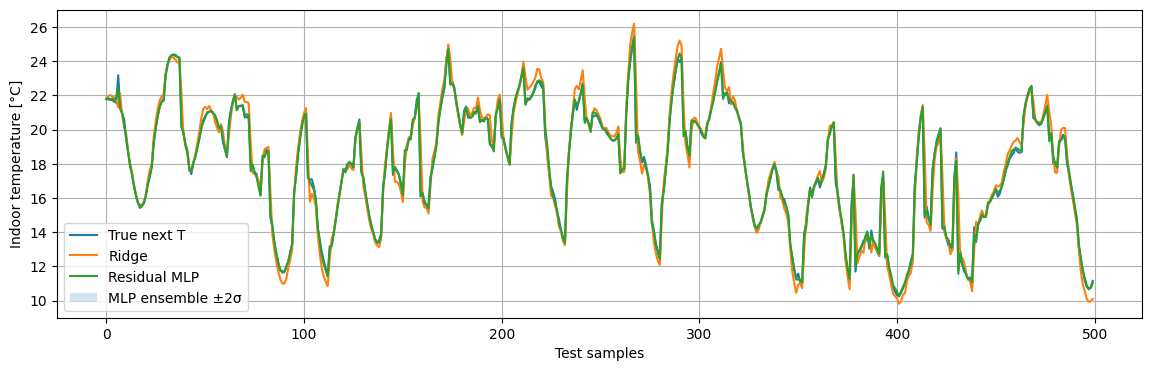

In [13]:
def predict_residual_ensemble_scaled(X):
    X_t = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    preds = []
    for model in models:
        model.eval()
        with torch.no_grad():
            preds.append(model(X_t).detach().cpu().numpy().ravel())
    preds = np.vstack(preds)
    return preds.mean(axis=0), preds.std(axis=0)

def predict_delta_deep(X):
    ridge_s = ridge.predict(X)
    resid_mean_s, resid_std_s = predict_residual_ensemble_scaled(X)
    total_s = ridge_s + resid_mean_s
    delta = inverse_delta(total_s)
    # approximate uncertainty in physical delta units
    delta_std = resid_std_s * float(y_scaler.scale_[0])
    return delta, delta_std

mlp_test_delta, mlp_test_delta_std = predict_delta_deep(X_test)
mlp_test_nextT = test_df["indoor_dry_bulb_temperature"].values + mlp_test_delta

one_step_results = [
    metrics(test_df["target_next_T"].values, ridge_test_nextT, "Ridge NARX one-step T"),
    metrics(test_df["target_next_T"].values, mlp_test_nextT, "Ridge + Residual MLP ensemble one-step T"),
]
one_step_table = pd.DataFrame(one_step_results)
display(one_step_table)

plt.figure(figsize=(14,4))
idx = np.arange(min(500, len(test_df)))
plt.plot(idx, test_df["target_next_T"].values[:len(idx)], label="True next T")
plt.plot(idx, ridge_test_nextT[:len(idx)], label="Ridge")
plt.plot(idx, mlp_test_nextT[:len(idx)], label="Residual MLP")
plt.fill_between(idx, mlp_test_nextT[:len(idx)]-2*mlp_test_delta_std[:len(idx)], mlp_test_nextT[:len(idx)]+2*mlp_test_delta_std[:len(idx)], alpha=0.2, label="MLP ensemble ±2σ")
plt.ylabel("Indoor temperature [°C]")
plt.xlabel("Test samples")
plt.legend()
plt.grid(True)
plt.show()

## 9. Recursive rollout evaluation

One-step metrics can look good while simulation performance is poor. For MPC, the important test is recursive rollout:

\[
\hat T_{k+1} \rightarrow \hat T_{k+2} \rightarrow \hat T_{k+3}
\]

In this evaluation, future weather/actions are taken from the true CityLearn trajectory, but temperature lags are replaced by the model's own predictions.

In [14]:
TEMP_COL = "indoor_dry_bulb_temperature"
LAG_COLS = [f"{TEMP_COL}_lag{lag}" for lag in LAGS if f"{TEMP_COL}_lag{lag}" in FEATURES]

def prepare_feature_row(row_dict):
    x = np.array([[row_dict.get(c, np.nan) for c in FEATURES]], dtype=np.float32)
    if np.isnan(x).any():
        # For safety; should not happen if the trajectory has enough history.
        x = np.nan_to_num(x, nan=0.0)
    return X_scaler.transform(x)

def predict_delta_from_row(row_dict, model_type="deep"):
    X = prepare_feature_row(row_dict)
    if model_type == "ridge":
        return float(inverse_delta(ridge.predict(X))[0])
    elif model_type == "deep":
        return float(predict_delta_deep(X)[0][0])
    else:
        raise ValueError(model_type)

def recursive_temperature_rollout(traj_df, model_type="deep", horizon=None):
    traj = traj_df.sort_values("t").copy().reset_index(drop=True)
    if horizon is not None:
        traj = traj.iloc[:horizon].copy()

    # Initialize history from true initial values for first lag window.
    true_T = traj[TEMP_COL].values.astype(float)
    pred_current = float(true_T[0])
    pred_series = []

    # history list stores previous predicted/current temperatures.
    history = [float(true_T[0])] * (max(LAGS)+1)

    for i in range(len(traj)):
        row = traj.iloc[i].to_dict()
        row[TEMP_COL] = pred_current

        for lag in LAGS:
            col = f"{TEMP_COL}_lag{lag}"
            if col in FEATURES:
                if i - lag >= 0:
                    row[col] = history[-lag]
                else:
                    # use true lag from available row for the very beginning
                    row[col] = traj.iloc[i].get(col, pred_current)

        delta = predict_delta_from_row(row, model_type=model_type)
        pred_next = pred_current + delta
        pred_series.append(pred_next)
        history.append(pred_next)
        pred_current = pred_next

    out = traj[["rollout", "t", "building_id", "building_name", "target_next_T"]].copy()
    out[f"pred_next_T_{model_type}"] = np.array(pred_series)
    return out

def evaluate_rollouts(test_df, model_type="deep", max_buildings=None, horizon=720):
    outs = []
    buildings = sorted(test_df["building_id"].unique())
    if max_buildings is not None:
        buildings = buildings[:max_buildings]
    for b in buildings:
        traj = test_df[test_df["building_id"] == b].copy()
        outs.append(recursive_temperature_rollout(traj, model_type=model_type, horizon=horizon))
    return pd.concat(outs, ignore_index=True)

roll_ridge = evaluate_rollouts(test_df, model_type="ridge", horizon=720)
roll_deep = evaluate_rollouts(test_df, model_type="deep", horizon=720)
roll = roll_ridge.merge(
    roll_deep[["building_id", "t", "pred_next_T_deep"]],
    on=["building_id", "t"], how="left"
)

rollout_results = [
    metrics(roll["target_next_T"], roll["pred_next_T_ridge"], "Ridge recursive rollout T"),
    metrics(roll["target_next_T"], roll["pred_next_T_deep"], "Ridge + Residual MLP recursive rollout T"),
]
rollout_table = pd.DataFrame(rollout_results)
display(rollout_table)

per_building = []
for b, g in roll.groupby("building_id"):
    per_building.append(metrics(g["target_next_T"], g["pred_next_T_deep"], f"building_{b}"))
per_building_table = pd.DataFrame(per_building)
display(per_building_table.sort_values("RMSE").head())
display(per_building_table.sort_values("RMSE").tail())

,model,RMSE,MAE,R2,NRMSE_range
0,Ridge recursive rollout T,3.126103,2.425008,0.549463,0.091998
1,Ridge + Residual MLP recursive rollout T,0.735863,0.501125,0.975036,0.021656


,model,RMSE,MAE,R2,NRMSE_range
8,building_8,0.266850,0.209686,0.991422,0.020052
24,building_24,0.272582,0.218337,0.991760,0.019706
22,building_22,0.351243,0.290667,0.978942,0.030299
11,building_11,0.384533,0.296346,0.988875,0.021242
21,building_21,0.407059,0.303881,0.984420,0.025393


,model,RMSE,MAE,R2,NRMSE_range
7,building_7,0.838687,0.621117,0.976117,0.032720
14,building_14,0.864830,0.598593,0.963233,0.035621
16,building_16,0.941082,0.765700,0.968946,0.032310
19,building_19,1.169139,0.803463,0.859717,0.051773
17,building_17,1.797499,1.445047,0.907209,0.065733


## 10. Rollout plots

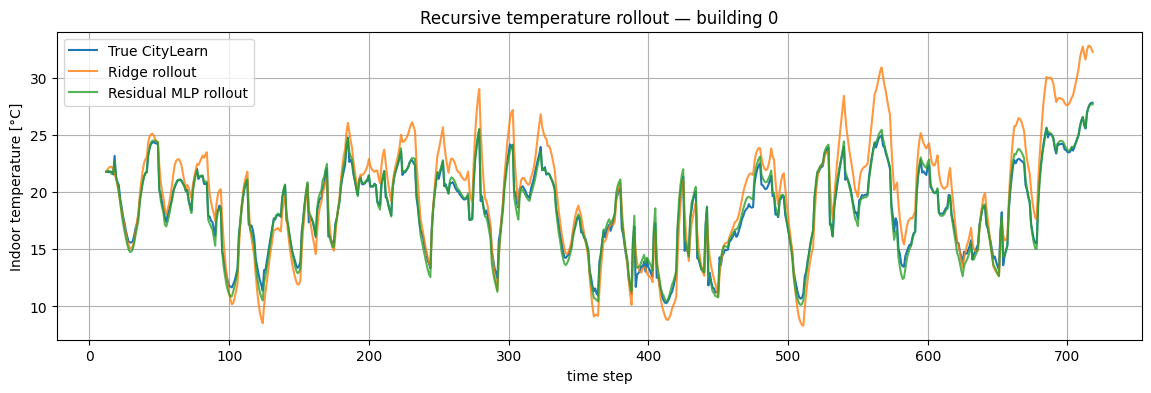

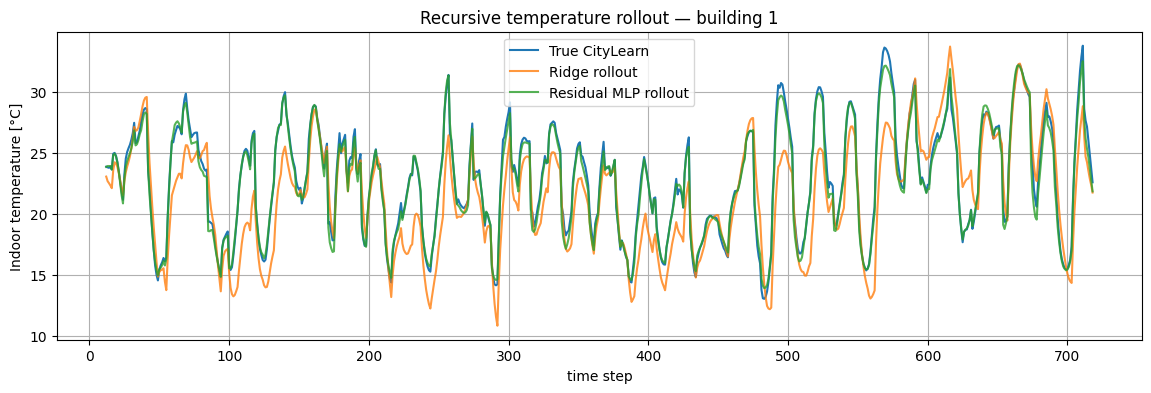

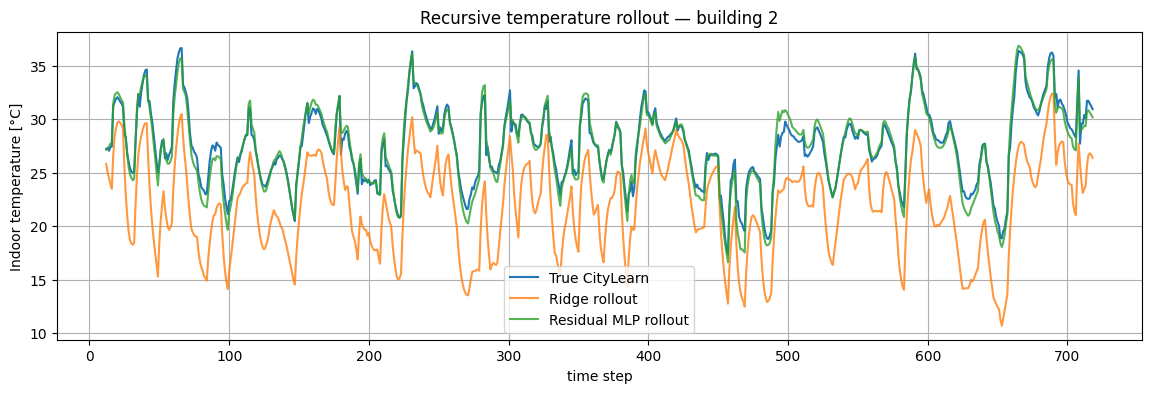

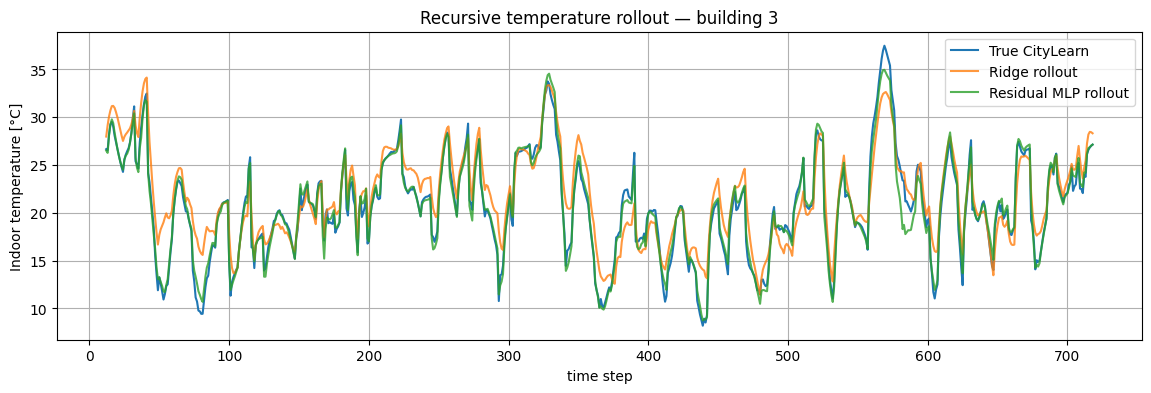

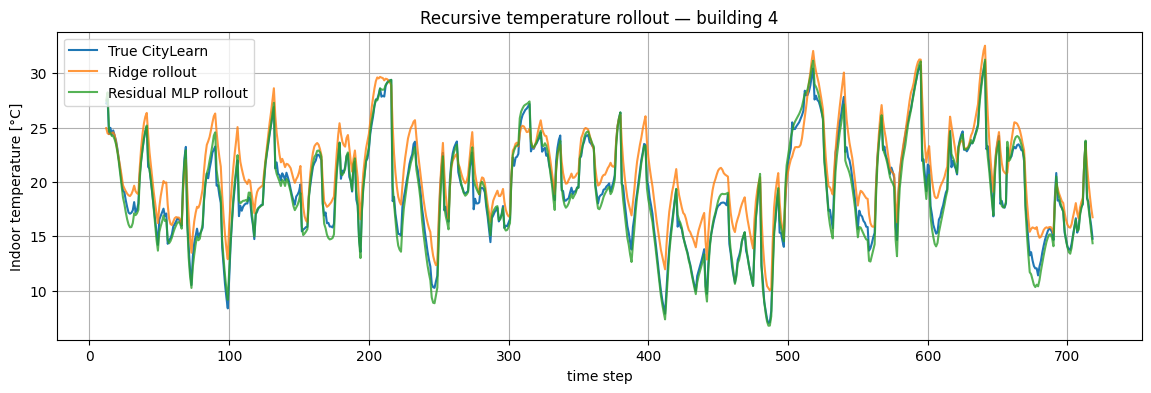

In [15]:
for b in sorted(roll["building_id"].unique())[:5]:
    g = roll[roll["building_id"] == b].sort_values("t")
    plt.figure(figsize=(14,4))
    plt.plot(g["t"], g["target_next_T"], label="True CityLearn")
    plt.plot(g["t"], g["pred_next_T_ridge"], label="Ridge rollout", alpha=0.8)
    plt.plot(g["t"], g["pred_next_T_deep"], label="Residual MLP rollout", alpha=0.8)
    plt.title(f"Recursive temperature rollout — building {b}")
    plt.xlabel("time step")
    plt.ylabel("Indoor temperature [°C]")
    plt.grid(True)
    plt.legend()
    plt.show()

## 11. Optional: one-step net-load surrogate

This is not the primary SID model. Net electricity is mostly an algebraic consequence of load, HVAC electricity, PV, and battery behavior. Still, a one-step net-load surrogate is useful as a diagnostic.

,model,RMSE,MAE,R2,NRMSE_range
0,Ridge one-step net load,1.598074,1.128623,0.576508,0.056493


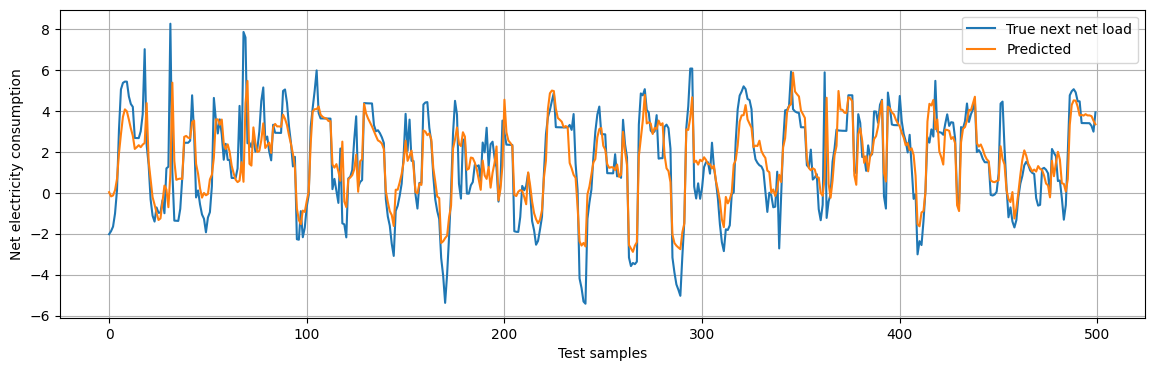

In [16]:
# Train a quick residual MLP for next net electricity consumption, if enough non-NaN values exist.
net_df = model_df.dropna(subset=FEATURES + ["target_next_net_load"]).copy()
train_net = net_df[net_df["rollout"].isin(train_rollouts)]
test_net = net_df[net_df["rollout"].isin(test_rollouts)]

if len(train_net) > 100 and len(test_net) > 100:
    Xn_scaler = StandardScaler()
    yn_scaler = StandardScaler()
    Xn_train = Xn_scaler.fit_transform(train_net[FEATURES].values.astype(np.float32))
    Xn_test = Xn_scaler.transform(test_net[FEATURES].values.astype(np.float32))
    yn_train = yn_scaler.fit_transform(train_net["target_next_net_load"].values.reshape(-1,1).astype(np.float32)).ravel()
    yn_test = test_net["target_next_net_load"].values.astype(float)

    ridge_net = Ridge(alpha=1.0).fit(Xn_train, yn_train)
    pred_net = yn_scaler.inverse_transform(ridge_net.predict(Xn_test).reshape(-1,1)).ravel()
    display(pd.DataFrame([metrics(yn_test, pred_net, "Ridge one-step net load")]))

    plt.figure(figsize=(14,4))
    n = min(500, len(yn_test))
    plt.plot(yn_test[:n], label="True next net load")
    plt.plot(pred_net[:n], label="Predicted")
    plt.ylabel("Net electricity consumption")
    plt.xlabel("Test samples")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("Skipping net-load surrogate due to insufficient data.")

## 12. Save trained SID artifacts

These files can later be loaded into an MPC script.

In [18]:
import joblib
SAVE_DIR = REPO_DIR / "System Identification" / "advanced_sid"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump({
    "features": FEATURES,
    "lags": LAGS,
    "x_scaler": X_scaler,
    "y_scaler": y_scaler,
    "ridge": ridge,
    "one_step_table": one_step_table,
    "rollout_table": rollout_table,
}, SAVE_DIR / "sid_preprocessing_and_ridge.joblib")

for i, model in enumerate(models):
    torch.save(model.state_dict(), SAVE_DIR / f"residual_mlp_seed_{ENSEMBLE_SEEDS[i]}.pt")

print("Saved artifacts to:", SAVE_DIR)
print("Main model form: delta_T = Ridge_NARX(features) + ResidualMLP(features)")

Saved artifacts to: c:\Users\yusuf\Documents\Python_Projects\CITYLEARN - Q4\annex96_common_exercise_1\System Identification\advanced_sid
Main model form: delta_T = Ridge_NARX(features) + ResidualMLP(features)


## 13. How to judge the result

Use these rules:

- **One-step RMSE** measures local prediction quality.
- **Recursive rollout RMSE** measures whether the SID is useful for MPC.
- If one-step RMSE is good but rollout RMSE is bad, the model is not stable enough for MPC.
- The residual MLP should beat Ridge in one-step prediction and ideally in recursive rollout.
- If rollout still drifts, increase data excitation, train per-building models, or move to a constrained neural state-space model.

Recommended next steps if rollout is still weak:

1. Increase `N_ROLLOUTS` to 20–50.
2. Train separate models per building or add a stronger building embedding model.
3. Use direct multi-step loss, not only one-step loss.
4. Keep battery SOC analytical and only learn thermal dynamics.
5. Add GP/ensemble uncertainty and make MPC robust to prediction uncertainty.